# Airbnb nightly price prediction

Project Goal: Predict the expected nightly price of an Airbnb stay in Sydney based on the user’s booking requirements and listing characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from functools import partial
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_validate, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 123
TARGET = 'price'

sns.set_theme(style = 'whitegrid')
pd.set_option("display.max_columns", 100)

In [2]:
# import data
df_airbnb = pd.read_csv('.\\dataset\\2026listings.csv')
print(f'The dataset contains {df_airbnb.shape[0]} rows and {df_airbnb.shape[1]} columns')
display(df_airbnb.head())

The dataset contains 20573 rows and 90 columns


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11156,https://www.airbnb.com/rooms/11156,20260616211453,2026-06-28,previous scrape,An Oasis in the City,Very central to the city which can be reached ...,NaN,https://a0.muscache.com/pictures/2797669/17895...,40855,https://www.airbnb.com/users/show/40855,1462507354016954190,https://www.airbnb.com/users/profile/146250735...,Colleen,NaN,16,9,15,5,"Potts Point, Australia","Recently retired, I've lived & worked on 4 con...",NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/40855/profile...,NaN,1,NaN,NaN,t,t,NaN,Sydney,NaN,-33.86767,151.22497,Private room in rental unit,Private room,1,NaN,1 shared bath,NaN,NaN,"[""Iron"", ""Dishwasher"", ""Wifi"", ""Hangers"", ""TV""...",$24.70,2026-06-30,2026-09-28,2223.0,24.7,"{""quote"": {""taxes"": null, ""currency"": ""AUD"", ""...",90.0,180.0,90.0,90.0,180.0,180.0,90.0,180.0,NaN,t,28,58,88,363,2026-06-28,193,0,0,185,0,0,0.0,2009-12-05,2020-03-13,4.59,4.76,4.30,4.80,4.76,4.82,4.71,NaN,NaN,1,0,1,0,0.96
1,15253,https://www.airbnb.com/rooms/15253,20260616211453,2026-06-17,city scrape,Unique Designer Rooftop Apartment in City Loca...,You will be staying in a unique apartment on t...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,59850,https://www.airbnb.com/users/show/59850,1462507959673254927,https://www.airbnb.com/users/profile/146250795...,Morag,NaN,16,6,14,4,"Sydney, Australia",I am originally Scottish but I have made Sydne...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/730ee...,NaN,1,NaN,NaN,t,t,NaN,Sydney,NaN,-33.87964,151.21680,Private room in condo,Private room,2,1.0,1 private bath,NaN,1.0,"[""Paid parking lot off premises"", ""Lock on bed...",$144.70,2026-06-17,2026-06-18,144.7,144.7,"{""quote"": {""taxes"": null, ""currency"": ""AUD"", ""...",1.0,1125.0,1.0,2.0,1125.0,1125.0,1.0,1125.0,NaN,t,17,46,54,199,2026-06-17,676,58,4,146,51,255,36899.0,2012-02-23,2026-06-14,4.56,4.66,4.54,4.82,4.76,4.77,4.58,PID-STRA-24061-7,NaN,1,0,1,0,3.88
2,44545,https://www.airbnb.com/rooms/44545,20260616211453,2026-06-28,previous scrape,Sunny Darlinghurst Warehouse Apartment,Sunny warehouse/loft apartment in the heart of...,NaN,https://a0.muscache.com/pictures/a88d8e14-4f63...,112237,https://www.airbnb.com/users/show/112237,1462509878415092926,https://www.airbnb.com/users/profile/146250987...,Atari,NaN,16,2,15,4,"Sydney, Australia",Curious about the w

In [3]:
def overview(df):
    ov = pd.DataFrame({
        'dtype' : df.dtypes.astype(str),
        'non_nul_cnt' : df.notna().sum(),
        'missing_cnt': df.isna().sum(),
        'missing_pct' : (df.isna().mean() * 100).round(2),
        'unique_values_cnt' : df.nunique(dropna = True)
    }).sort_values(by = 'missing_cnt', ascending = False)
    return ov

## 🧼 Dataset Cleaning

In [4]:
def data_cleaning(dataset):
    def map_tf(series):
        return (series.map({'t': 1, 'f': 0}).astype('Int64'))
    
    df = dataset.copy()
    cols = [
        'id', 'last_scraped', 'host_is_superhost', 'host_listings_count', 'host_has_profile_pic',
        'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
        'room_type','accommodates', 'bathrooms_text','bedrooms', 'bathrooms', 'beds', 'amenities',
        'availability_30', 'availability_90', 'availability_365',
        'number_of_reviews','number_of_reviews_ltm','number_of_reviews_l30d', 'review_scores_rating',
        'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 
        'review_scores_communication', 'review_scores_location', 'review_scores_value',
        'license', 'price_quote_total_price','price_quote_checkin_date','price_quote_checkout_date'
    ]

    df = df[cols].copy()
    
    # Boolean cols
    tf_cols = [
        'host_is_superhost', 'host_has_profile_pic','host_identity_verified'
    ]

    for col in tf_cols:
        if col in df.columns:
            df[col] = map_tf(df[col])
    
    df['year'] = pd.to_datetime(df['last_scraped'], errors='coerce').dt.year

    # bathrooms
    text = df['bathrooms_text'].astype('string').str.lower()
    extracted = (text.str.extract(r'(\d+(?:\.\d+)?)', expand=False).astype(float))
    extracted = extracted.mask(extracted.isna() & text.str.contains('half', na=False), 0.5)
    df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce').fillna(extracted)


    
    # amenities
    amenities = df['amenities'].fillna('[]').astype('string').str.strip()
    
    df['amenity_cnt'] = amenities.str.count(r'"\s*,\s*"').add(1)
    df.loc[amenities.isin(['', '[]']), 'amenity_cnt'] = 0
    
    amenities = amenities.str.lower()
    
    features = {
        'has_wifi': r'wifi',
        'has_air_conditioning': r'air conditioning',
        'has_kitchen': r'kitchen',
        'has_parking': r'parking',
        'has_pool': r'pool',
        'has_washer': r'washer',
        'has_water_view': r'ocean view|sea view|harbor view|water view|river view|lake view',
        'pets_allowed': r'pets allowed',
        'has_tub': r'bathtub|hot tub',
        'has_heating': r'heating|heater'
    }
    for new_col, pattern in features.items():
        df[new_col] = amenities.str.contains(pattern, regex=True, na=False).astype(int)

    #license
    df['has_license'] = (df['license'].astype('string').str.strip().ne('').fillna(False).astype(int))

    # check in/out
    checkin = pd.to_datetime(df['price_quote_checkin_date'], errors='coerce')
    checkout = pd.to_datetime(df['price_quote_checkout_date'], errors='coerce')
    df['checkin_month'] = checkin.dt.month
    df['checkin_day_of_week'] = checkin.dt.dayofweek
    df['stay_length_nights'] = (checkout - checkin).dt.days

    # price target
    df['price_quote_total_price'] = pd.to_numeric(df['price_quote_total_price'],errors='coerce')

    df['price'] = (df['price_quote_total_price']/ df['stay_length_nights'])
    
    df = df.rename(columns={
        'id' : 'listing_id',
        'neighbourhood_cleansed' : 'location',
    })
    
    df = df.dropna(subset=['price']).reset_index(drop=True)
    
    return df.drop(columns = [
        'last_scraped', 'bathrooms_text','amenities',
        'license','price_quote_checkin_date',
        'price_quote_checkout_date','price_quote_total_price'
    ])

In [5]:
df = data_cleaning(df_airbnb)
print(f'Before cleaning: The dataset contains {df_airbnb.shape[0]} rows and {df_airbnb.shape[1]} columns')
print(f'After cleaning: The dataset contains {df.shape[0]} rows and {df.shape[1]} columns')
print(f'Duplicate: {df_airbnb.duplicated().sum()}')
display(df.head(5))

Before cleaning: The dataset contains 20573 rows and 90 columns
After cleaning: The dataset contains 17784 rows and 44 columns
Duplicate: 0


,listing_id,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,location,latitude,longitude,property_type,room_type,accommodates,bedrooms,bathrooms,beds,availability_30,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,year,amenity_cnt,has_wifi,has_air_conditioning,has_kitchen,has_parking,has_pool,has_washer,has_water_view,pets_allowed,has_tub,has_heating,has_license,checkin_month,checkin_day_of_week,stay_length_nights,price
0,11156,0,1,1,1,Sydney,-33.86767,151.22497,Private room in rental unit,Private room,1,NaN,1.0,NaN,28,88,363,193,0,0,4.59,4.76,4.30,4.80,4.76,4.82,4.71,2026,27,1,0,1,0,0,1,0,0,0,1,0,6.0,1.0,90.0,24.7
1,15253,0,1,1,1,Sydney,-33.87964,151.21680,Private room in condo,Private room,2,NaN,1.0,1.0,17,54,199,676,58,4,4.56,4.66,4.54,4.82,4.76,4.77,4.58,2026,49,1,1,1,1,0,0,1,1,0,1,1,6.0,2.0,1.0,144.7
2,58506,1,1,1,1,Mosman,-33.81748,151.23484,Entire guest suite,Entire home/apt,4,1.0,1.0,3.0,0,17,206,482,35,3,4.65,4.73,4.36,4.90,4.92,4.77,4.73,2026,50,1,0,1,1,0,1,0,0,0,1,1,8.0,6.0,2.0,240.0
3,1141803,1,1,1,1,Sydney,-33.88706,151.21403,Entire loft,Entire home/apt,2,1.0,1.0,1.0,23,66,171,150,21,0,4.94,4.95,4.87,4.96,4.97,5.00,4.83,2026,48,1,0,1,1,0,1,0,0,1,1,1,6.0,6.0,4.0,456.5
4,1145571,0,2,1,1,Leichhardt,-33.86572,151.17114,Private room in home,Private room,1,NaN,2.0,NaN,29,89,364,3,0,0,4.67,4.33,4.33,4.67,4.67,4.67,4.33,2026,8,0,0,1,1,0,0,0,0,0,0,1,6.0,0.0,90.0,32.3


In [6]:
overview(df)

,dtype,non_nul_cnt,missing_cnt,missing_pct,unique_values_cnt
review_scores_cleanliness,float64,14990,2794,15.71,178
review_scores_value,float64,14990,2794,15.71,163
review_scores_communication,float64,14990,2794,15.71,132
review_scores_checkin,float64,14990,2794,15.71,136
review_scores_accuracy,float64,14990,2794,15.71,148
review_scores_location,float64,14990,2794,15.71,136
review_scores_rating,float64,14992,2792,15.70,155
bedrooms,float64,15058,2726,15.33,14
beds,float64,15438,2346,13.19,21
bathrooms,float64,17762,22,0.12,21


In [7]:
# Inspect missingness by month, room type, and location
cols_to_check = [
    'review_scores_rating',
    'bedrooms',
    'beds',
    'bathrooms'
]

missing_by_month = (
    df.groupby('checkin_month')[cols_to_check]
      .agg(lambda x: x.isna().mean() * 100)
).round(2)

missing_by_room_type = (
    df.groupby('room_type')[cols_to_check]
      .agg(lambda x: x.isna().mean() * 100)
).round(2)

missing_by_location = (
    df.groupby('location')[cols_to_check]
      .agg(lambda x: x.isna().mean() * 100)
).round(2)

display(missing_by_month)
display(missing_by_room_type)
display(missing_by_location)

,review_scores_rating,bedrooms,beds,bathrooms
checkin_month,,,,
1.0,16.06,13.76,27.06,0.00
2.0,27.10,6.54,28.97,0.00
3.0,17.24,9.20,40.23,0.00
4.0,18.92,2.70,13.51,0.00
5.0,12.00,4.00,4.00,0.00
6.0,15.61,16.24,10.50,0.13
7.0,17.04,13.29,21.47,0.08
8.0,13.90,13.32,12.61,0.14
9.0,7.69,17.86,18.13,0.00


,review_scores_rating,bedrooms,beds,bathrooms
room_type,,,,
Entire home/apt,13.82,5.50,10.92,0.01
Hotel room,1.96,19.61,5.88,1.96
Private room,22.46,50.44,21.40,0.49
Shared room,30.77,15.38,15.38,0.00


,review_scores_rating,bedrooms,beds,bathrooms
location,,,,
Ashfield,24.21,15.79,15.79,3.16
Auburn,13.53,12.72,5.31,0.00
Bankstown,11.54,23.46,9.23,0.00
Blacktown,21.63,28.93,20.22,0.00
Botany Bay,26.92,15.66,12.91,0.00
Burwood,24.14,16.26,12.32,1.97
Camden,11.30,14.78,10.43,0.00
Campbelltown,10.69,17.56,7.63,0.76
Canada Bay,13.55,23.36,16.36,0.00


Missingness varies more strongly by room type and location than by month. Private rooms have particularly high missingness in bedrooms, while several locations show noticeably higher missing rates for review scores and property attributes.

In [8]:
discrete_num_cols = [
    'bedrooms',
    'beds',
    'bathrooms',
    'accommodates'
]

continuous_num_cols = [
    'stay_length_nights',
    'amenity_cnt',
    'number_of_reviews',
    'number_of_reviews_ltm',
    'number_of_reviews_l30d',
    'host_listings_count',
    'availability_30',
    'availability_90',
    'availability_365',
    'review_scores_rating',
    'review_scores_accuracy', 
    'review_scores_cleanliness', 
    'review_scores_checkin', 
    'review_scores_communication', 
    'review_scores_location', 
    'review_scores_value',
    'latitude',
    'longitude'
]

binary_cols = [
    'has_wifi',
    'has_air_conditioning',
    'has_kitchen',
    'has_parking',
    'has_pool',
    'has_washer',
    'has_water_view',
    'pets_allowed',
    'has_tub',
    'has_heating',
    'has_license',
    'host_has_profile_pic',
    'host_identity_verified',
    'host_is_superhost'
]

categorical_cols = [
    'property_type',
    'location',
    'room_type'
]

calendar_cols = [
    'checkin_month',
    'checkin_day_of_week'
]

In [9]:
# Check the percentiles on numerical columns
df[continuous_num_cols].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99],include='number').T

,count,mean,std,min,1%,25%,50%,75%,99%,max
stay_length_nights,17784.0,12.212157,28.512642,1.0,1.0,1.0,2.0,4.0,90.0,365.0
amenity_cnt,17784.0,37.474921,15.845432,0.0,6.0,27.0,38.0,49.0,74.0,113.0
number_of_reviews,17784.0,41.575742,76.404903,0.0,0.0,2.0,13.0,47.0,374.0,1158.0
number_of_reviews_ltm,17784.0,11.619152,15.583183,0.0,0.0,0.0,5.0,17.0,67.0,310.0
number_of_reviews_l30d,17784.0,0.755679,1.380641,0.0,0.0,0.0,0.0,1.0,6.0,31.0
host_listings_count,17784.0,24.080747,49.810772,0.0,1.0,1.0,4.0,24.0,202.0,667.0
availability_30,17784.0,16.858468,10.56797,0.0,0.0,8.0,18.0,28.0,30.0,30.0
availability_90,17784.0,57.881073,28.855269,0.0,0.0,36.0,65.0,84.0,90.0,90.0
availability_365,17784.0,198.86173,115.62325,0.0,8.0,90.0,189.0,312.0,365.0,365.0
review_scores_rating,14992.0,4.714691,0.430024,1.0,3.0,4.64,4.83,4.97,5.0,5.0


host_listings_count, number_of_reviews, and stay_length_nights, are likely skewed.

## 📊 Target Analysis

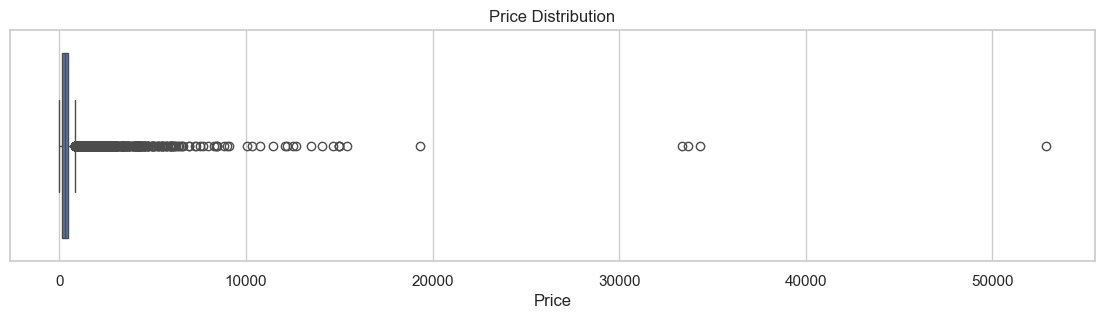

In [10]:
# Check target distribution
plt.figure(figsize = (14,3))

sns.boxplot(df[TARGET], orient = 'h')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.show()

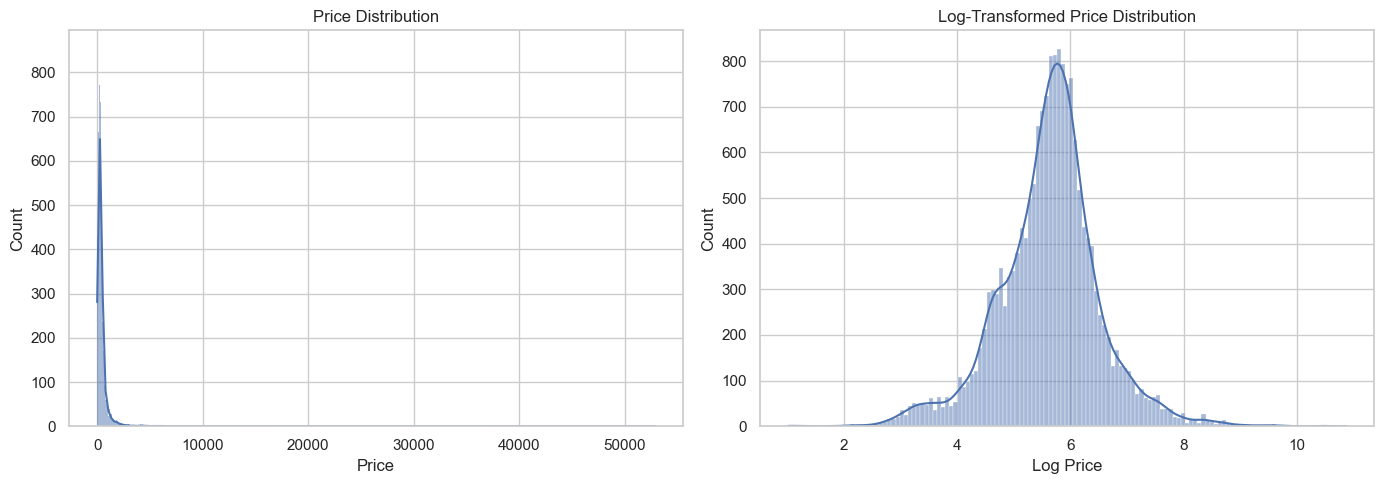

In [11]:
# Compare target distribution and log target distribution
fig, axes = plt.subplots(1, 2, figsize = (14,5))

sns.histplot(data = df, x = TARGET, kde = True, ax = axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')

sns.histplot(data = df, x= np.log1p(df[TARGET]), kde = True, ax = axes[1])
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('Log Price')

plt.tight_layout()
plt.show()

The target variable is strongly right-skewed, with a small number of unusually large values. Applying a log transformation reduces the influence of these extreme observations and produces a more symmetric, approximately normal distribution. This can improve linear-model performance by stabilising variance and helping the data better satisfy model assumptions.

In [12]:
# Create target classes for stratified train–test splitting,
# ensuring that each set contains similar proportions of each price range.

q25, q75, q99 = df["price"].quantile([0.25, 0.75, 0.99])

df["price_class"] = pd.cut(
    df["price"],
    bins=[-float("inf"), q25, q75, q99, float("inf")],
    labels=["Low", "Medium", "High", "Extreme High"],
    include_lowest=True
)
df['price_class'].value_counts(normalize=True)

price_class
Medium          0.500056
Low             0.250000
High            0.239935
Extreme High    0.010009
Name: proportion, dtype: float64

### ✂️ Train-Test Split

In [13]:
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['price_class'], random_state= RANDOM_STATE)
df_ratio = pd.DataFrame({
    'Train' : df_train['price_class'].value_counts(normalize=True),
    'Test' : df_test['price_class'].value_counts(normalize=True)
})
display(df_ratio)
print(f'Train: {df_train.shape}')
print(f'Test: {df_test.shape}')

,Train,Test
price_class,,
Medium,0.500035,0.500141
Low,0.250018,0.249930
High,0.239966,0.239809
Extreme High,0.009981,0.010121


Train: (14227, 45)
Test: (3557, 45)


In [14]:
df_train = df_train.drop(columns = ['price_class'])
df_test = df_test.drop(columns = ['price_class'])

## 🔍 EDA on training data

In [15]:
df_eda = df_train.copy()

In [16]:
df_eda['Log_Price'] = np.log1p(df_eda[TARGET])

In [17]:
# Inspect discrete features
for i in discrete_num_cols:
    print(df_eda[i].value_counts().sort_index())
    print('-' * 50)

bedrooms
0.0        1
1.0     5065
2.0     3782
3.0     1739
4.0      942
5.0      408
6.0       92
7.0       11
8.0       11
9.0        5
10.0       2
11.0       3
13.0       1
Name: count, dtype: int64
--------------------------------------------------
beds
1.0     4808
2.0     3167
3.0     2045
4.0     1153
5.0      634
6.0      290
7.0      128
8.0       75
9.0       29
10.0      17
11.0       7
12.0       8
13.0       6
14.0       2
15.0       2
16.0       3
22.0       1
28.0       1
50.0       1
Name: count, dtype: int64
--------------------------------------------------
bathrooms
0.0      132
0.5       67
1.0     8531
1.5      687
2.0     3210
2.5      513
3.0      601
3.5      165
4.0      152
4.5       65
5.0       48
5.5       16
6.0        4
6.5        4
7.0        5
8.0        3
9.0        1
11.0       2
12.0       1
21.0       1
Name: count, dtype: int64
--------------------------------------------------
accommodates
1      829
2     4880
3      932
4     3158
5      933
6

The capacity-related features are concentrated among smaller listings. Most properties have 1–3 bedrooms, 1–4 beds, 1–2 bathrooms, and accommodate 2–6 guests.

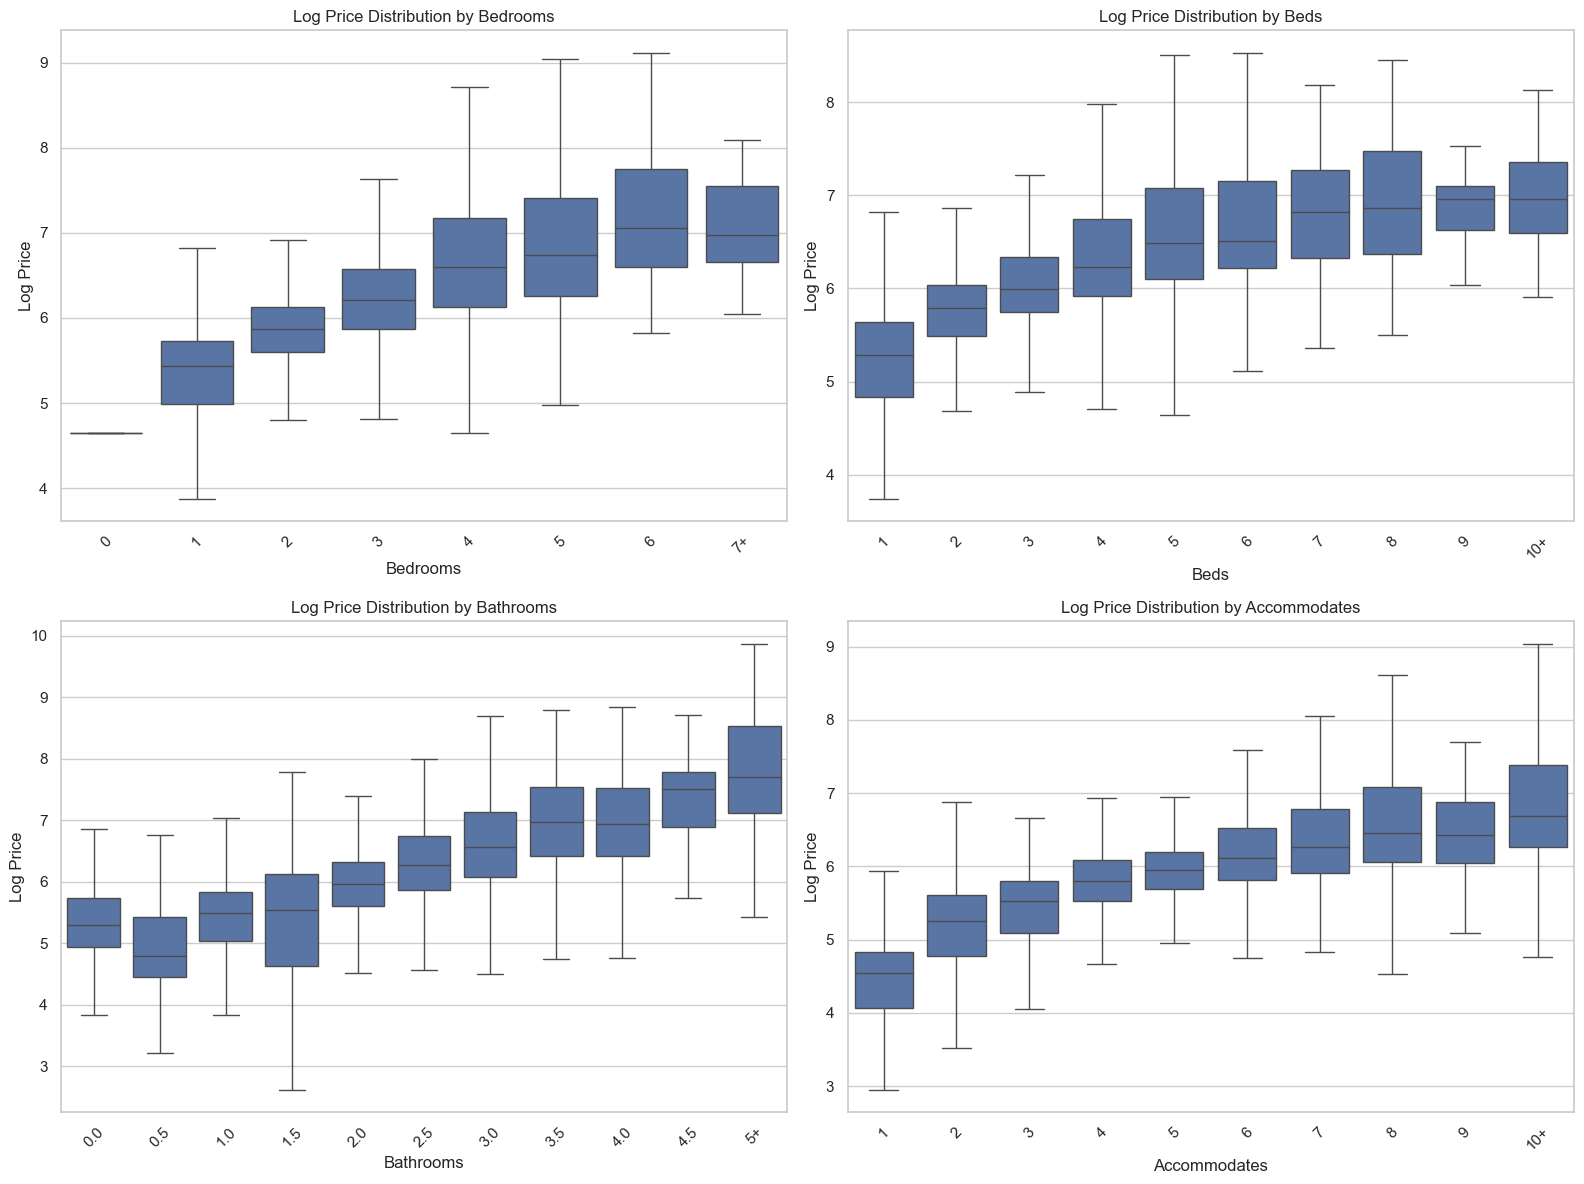

In [18]:
# Group rare large values
df_eda['bedrooms_grouped'] = np.where(
    df_eda['bedrooms'] >= 7,
    '7+',
    df_eda['bedrooms'].astype('Int64').astype(str)
)

df_eda['beds_grouped'] = np.where(
    df_eda['beds'] >= 10,
    '10+',
    df_eda['beds'].astype('Int64').astype(str)
)

df_eda['bathrooms_grouped'] = np.where(
    df_eda['bathrooms'] >= 5,
    '5+',
    df_eda['bathrooms'].astype(str)
)

df_eda['accommodates_grouped'] = np.where(
    df_eda['accommodates'] >= 10,
    '10+',
    df_eda['accommodates'].astype(str)
)

category_orders = {
    'bedrooms_grouped': [
        '0', '1', '2', '3', '4', '5', '6', '7+'
    ],
    'beds_grouped': [
        '1', '2', '3', '4', '5', '6', '7', '8', '9', '10+'
    ],
    'bathrooms_grouped': [
        '0.0', '0.5', '1.0', '1.5', '2.0',
        '2.5', '3.0', '3.5', '4.0', '4.5', '5+'
    ],
    'accommodates_grouped': [
        '1', '2', '3', '4', '5', '6', '7', '8', '9', '10+'
    ]
}
features = [
    ('bedrooms_grouped', 'Bedrooms'),
    ('beds_grouped', 'Beds'),
    ('bathrooms_grouped', 'Bathrooms'),
    ('accommodates_grouped', 'Accommodates')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (col, title) in zip(axes, features):
    sns.boxplot(
        data=df_eda,
        x=col,
        y='Log_Price',
        order=category_orders[col],
        ax=ax,
        showfliers=False # Hide outlier points to make the main distribution easier to inspect
    )

    ax.set_title(f'Log Price Distribution by {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Log Price')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Overall, the box plots suggest a positive association between property capacity and price. Median price generally increases as the number of bedrooms, beds, bathrooms, and accommodated guests increases.

In [19]:
# Inspect correlation between similar features
display(df_eda[['number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d']].corr())
display(df_eda[['availability_30','availability_90','availability_365',]].corr())
display(df_eda[[
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',  
    'review_scores_checkin', 'review_scores_communication',  'review_scores_location', 'review_scores_value',
]].corr())

,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d
number_of_reviews,1.000000,0.640027,0.351141
number_of_reviews_ltm,0.640027,1.000000,0.638372
number_of_reviews_l30d,0.351141,0.638372,1.000000


,availability_30,availability_90,availability_365
availability_30,1.000000,0.817442,0.385837
availability_90,0.817442,1.000000,0.524147
availability_365,0.385837,0.524147,1.000000


,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
review_scores_rating,1.000000,0.872584,0.827762,0.704310,0.765851,0.672971,0.857638
review_scores_accuracy,0.872584,1.000000,0.788021,0.683147,0.741883,0.695741,0.833380
review_scores_cleanliness,0.827762,0.788021,1.000000,0.600078,0.647430,0.599844,0.766418
review_scores_checkin,0.704310,0.683147,0.600078,1.000000,0.747757,0.566154,0.659530
review_scores_communication,0.765851,0.741883,0.647430,0.747757,1.000000,0.610327,0.740172
review_scores_location,0.672971,0.695741,0.599844,0.566154,0.610327,1.000000,0.657999
review_scores_value,0.857638,0.833380,0.766418,0.659530,0.740172,0.657999,1.000000


Strong correlations are present among the availability features, review-score features. In particular, availability_30 and availability_90 are highly correlated, while review_scores_rating is strongly correlated with several of its component scores.
These relationships indicate possible feature redundancy and multicollinearity, which will be investigated and addressed during feature selection.

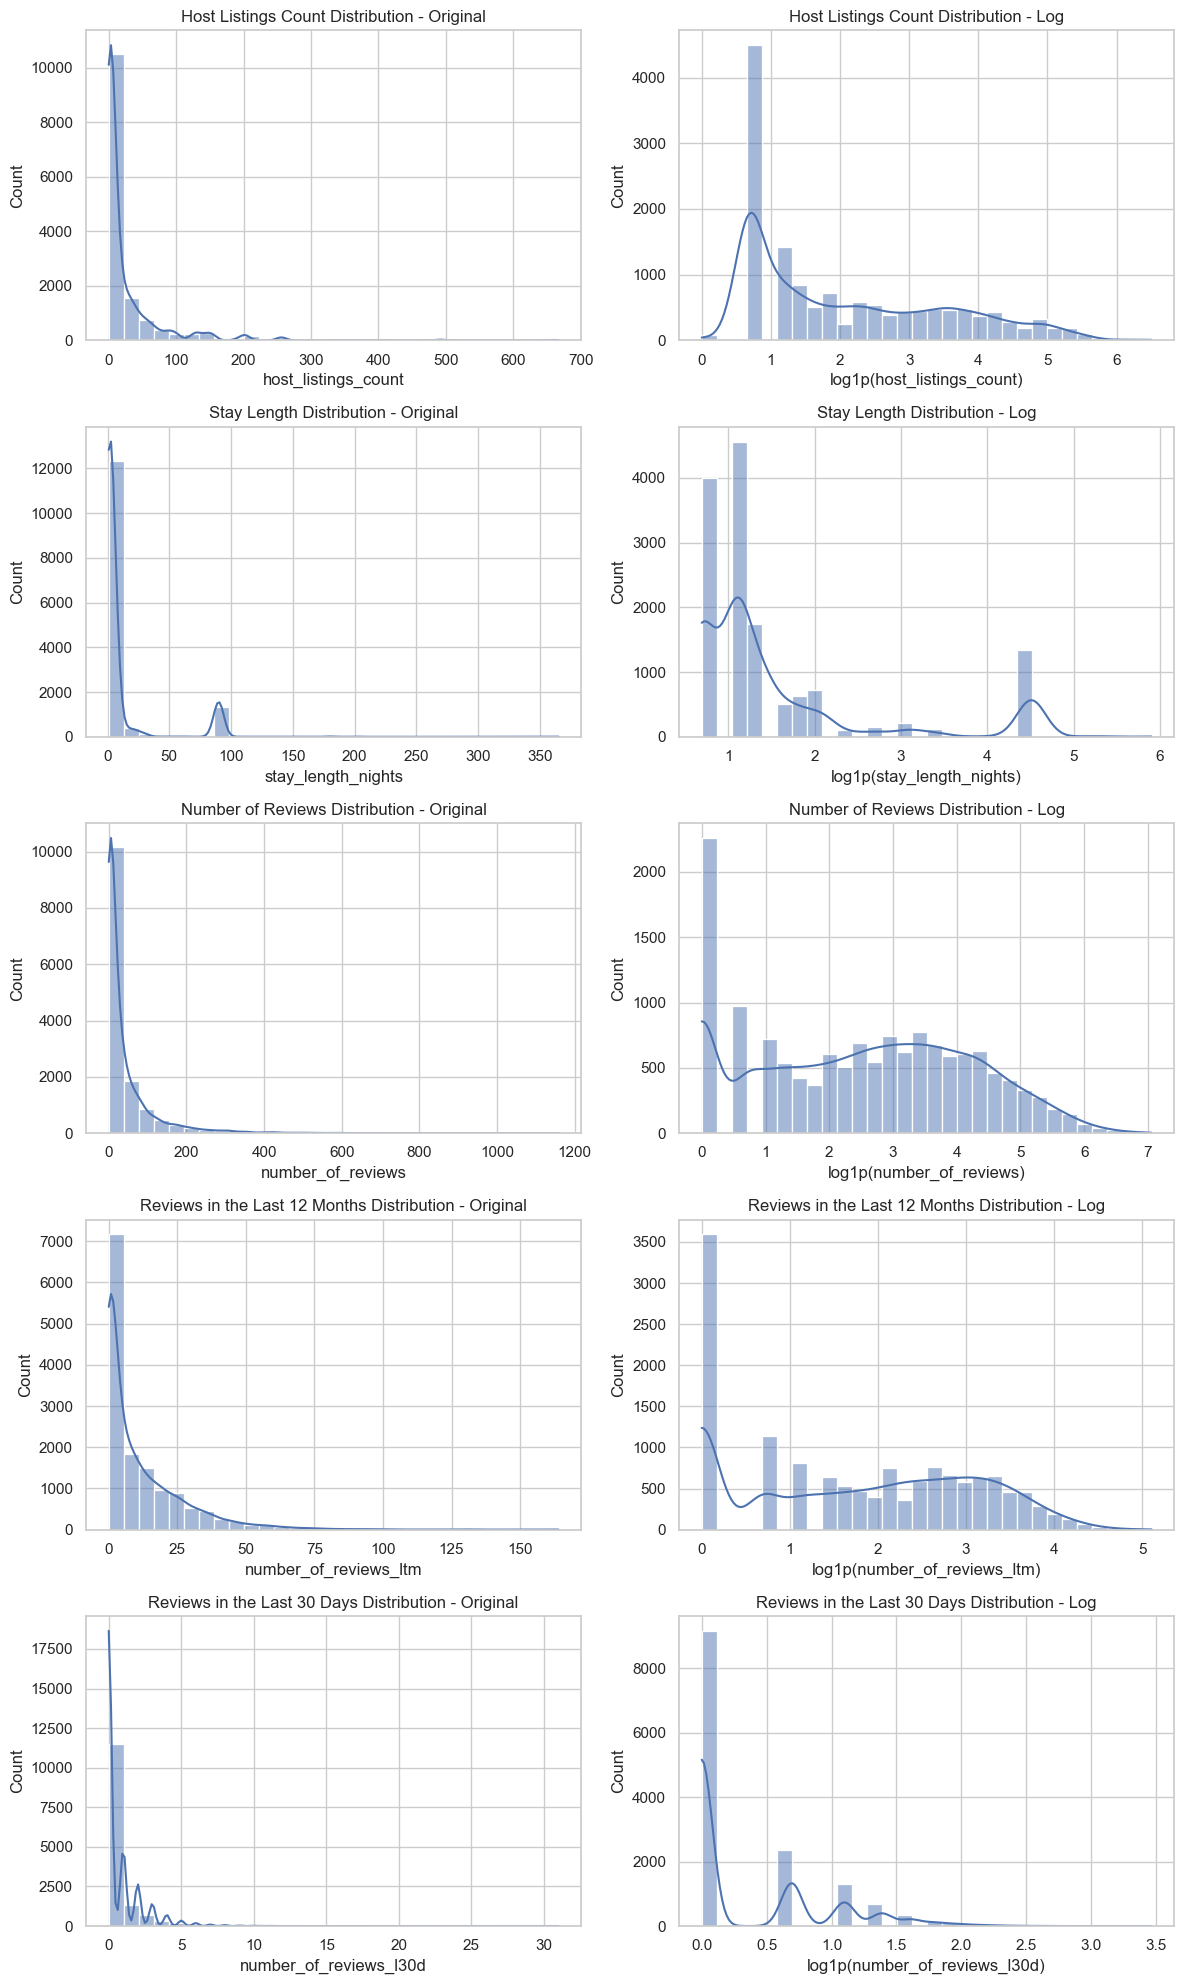

In [20]:
# Check skewed features and compare their original and log-transformed distributions
cols = [
    ('host_listings_count', 'Host Listings Count Distribution'),
    ('stay_length_nights', 'Stay Length Distribution'),
    ('number_of_reviews', 'Number of Reviews Distribution'),
    ('number_of_reviews_ltm', 'Reviews in the Last 12 Months Distribution'),
    ('number_of_reviews_l30d', 'Reviews in the Last 30 Days Distribution')
]

fig, axes = plt.subplots(len(cols), 2, figsize=(12, 4 * len(cols)))

for i, (col, title) in enumerate(cols):

    sns.histplot(df_train[col], ax=axes[i, 0], kde=True, bins=30)
    axes[i, 0].set_title(f"{title} - Original")
    axes[i, 0].set_xlabel(col)

    sns.histplot(np.log1p(df_train[col]), ax=axes[i, 1], kde=True, bins=30)
    axes[i, 1].set_title(f"{title} - Log")
    axes[i, 1].set_xlabel(f"log1p({col})")

plt.tight_layout()
plt.show()

These features are strongly right-skewed, so log1p will be applied during feature engineering. Selected features will also be grouped into meaningful bins where the distributions show clear clusters.

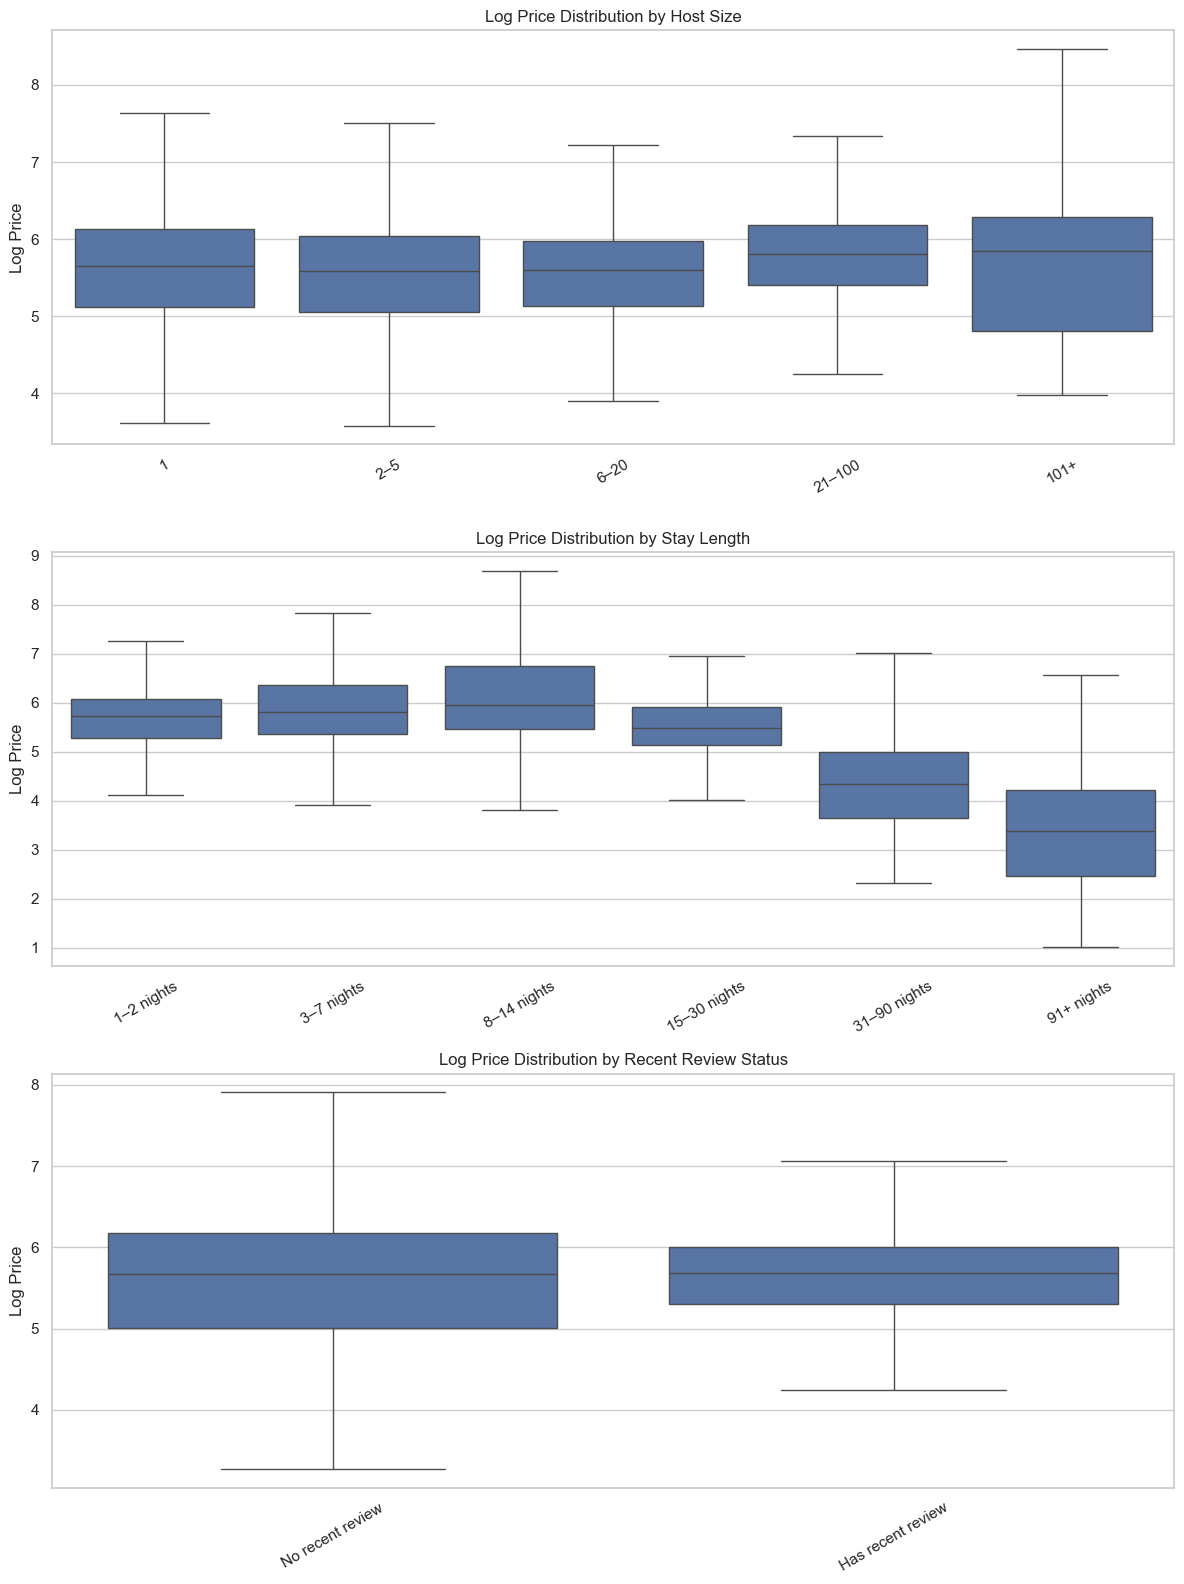

In [21]:
# Discretization
df_eda['host_size_group'] = pd.cut(
    df_eda['host_listings_count'],
    bins=[0, 1, 5, 20, 100, np.inf],
    labels=[
        '1',
        '2–5',
        '6–20',
        '21–100',
        '101+'
    ]
)
df_eda['stay_length_group'] = pd.cut(
    df_eda['stay_length_nights'],
    bins=[0, 2, 7, 14, 30, 90, np.inf],
    labels=[
        '1–2 nights',
        '3–7 nights',
        '8–14 nights',
        '15–30 nights',
        '31–90 nights',
        '91+ nights'
    ]
)
df_eda['has_recent_review'] = np.where(
    df_eda['number_of_reviews_l30d'] > 0,
    'Has recent review',
    'No recent review'
)

features = [
    ('host_size_group', 'Log Price Distribution by Host Size'),
    ('stay_length_group', 'Log Price Distribution by Stay Length'),
    ('has_recent_review', 'Log Price Distribution by Recent Review Status')
]

fig, axes = plt.subplots(3, 1, figsize=(12, 16))

for ax, (col, title) in zip(axes, features):
    sns.boxplot(
        data=df_eda,
        x=col,
        y='Log_Price',
        ax=ax,
        showfliers=False
    )

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Log Price')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Host size shows a modest positive association with price, particularly among hosts with more than 20 listings. In contrast, longer stays are associated with substantially lower prices, especially beyond 30 nights. Recent review status shows little difference in median price and may provide limited predictive value on its own.

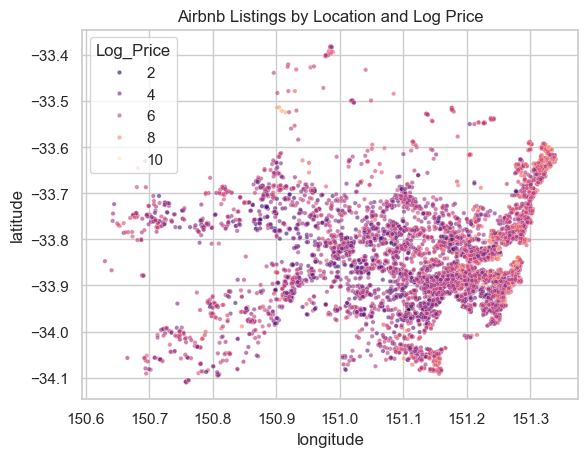

In [22]:
sns.scatterplot(
    data=df_eda,
    x='longitude',
    y='latitude',
    hue= 'Log_Price',
    palette="magma",
    s=10,
    alpha=0.6,
)

plt.title('Airbnb Listings by Location and Log Price')
plt.show()

higher-priced listings cluster more around Sydney’s eastern/coastal areas, while lower-to-mid-priced listings are more widely distributed.

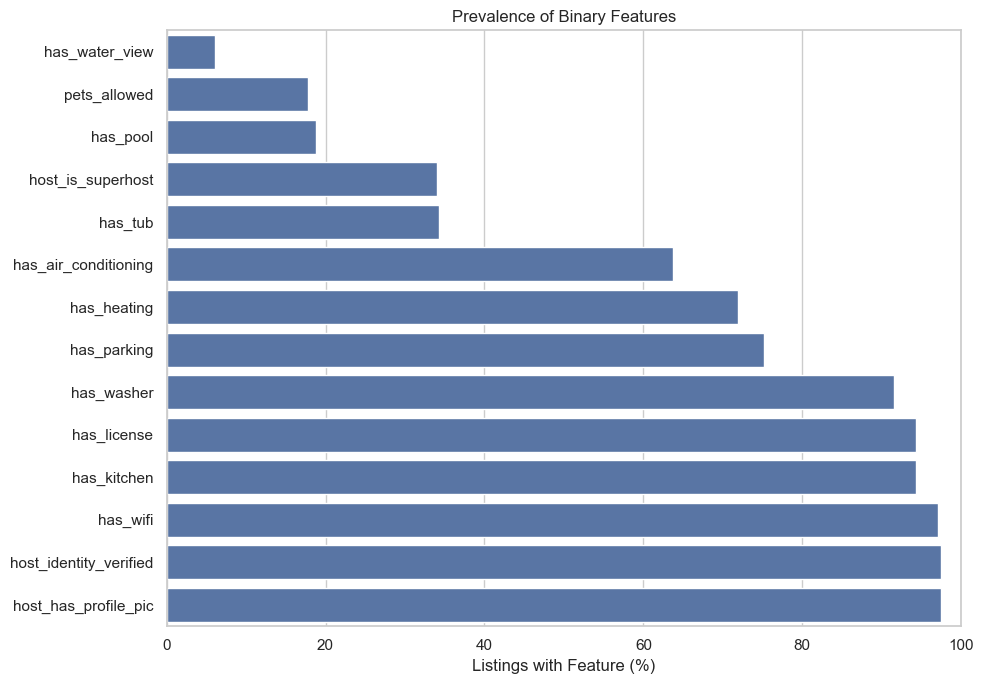

In [23]:
#Check Binary features
binary_pct = (
    df_eda[binary_cols]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=binary_pct.values,
    y=binary_pct.index
)

plt.title('Prevalence of Binary Features')
plt.xlabel('Listings with Feature (%)')
plt.ylabel('')
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

Most listings include basic amenities such as Wi-Fi, a kitchen, a host profile picture, and verified host identity. Washers, parking, heating, and air conditioning are also common. In contrast, pools, pet-friendly options, and especially water views are relatively uncommon, so these features may help distinguish listings.

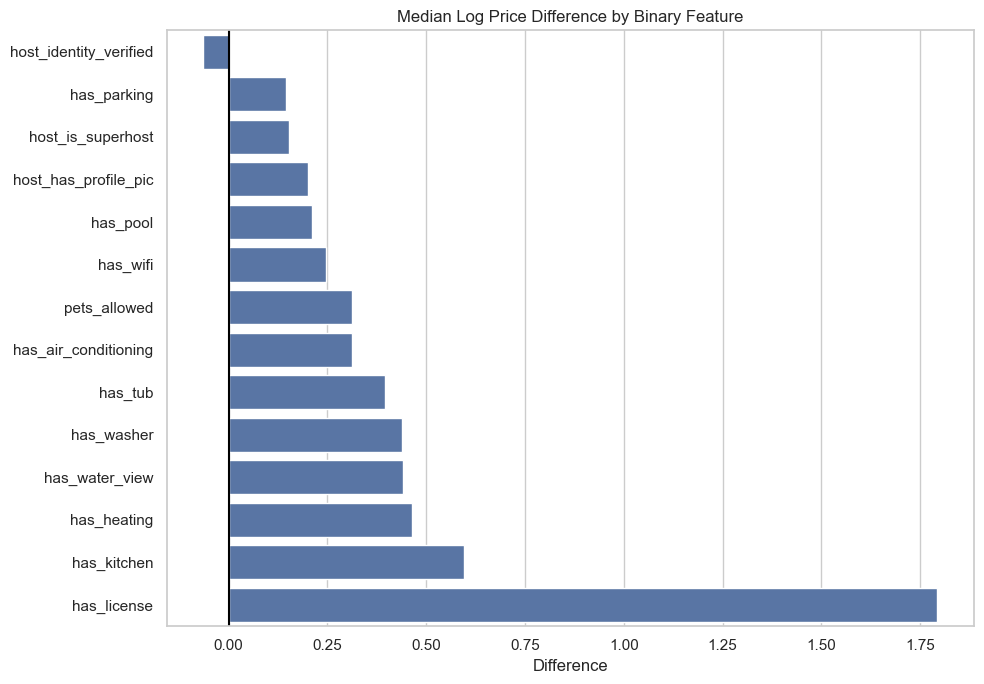

In [24]:
# Compare median log prices between listings with and without each binary feature
median_diff = {}

for col in binary_cols:
    with_feature = df_eda.loc[df_eda[col] == 1, 'Log_Price'].median()
    without_feature = df_eda.loc[df_eda[col] == 0, 'Log_Price'].median()

    median_diff[col] = with_feature - without_feature

plot_data = (
    pd.Series(median_diff)
    .sort_values()
    .reset_index()
)

plot_data.columns = ['feature', 'median_difference']

plt.figure(figsize=(10, 7))

sns.barplot(
    data=plot_data,
    x='median_difference',
    y='feature'
)

plt.axvline(0, color='black')
plt.title('Median Log Price Difference by Binary Feature')
plt.xlabel('Difference')
plt.ylabel('')

plt.tight_layout()
plt.show()

Listings with a licence show by far the largest positive difference in median log price. Kitchens, heating, water views, washers, and tubs are also associated with higher median prices, while host identity verification shows a slight negative difference. These are associations, not necessarily causal effects.

In [25]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

month_names = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}
df_eda['checkin_day_of_week'] = df_eda['checkin_day_of_week'].replace(day_names)
df_eda['checkin_month'] = df_eda['checkin_month'].replace(month_names)
top_15_location = df_eda['location'].value_counts(ascending = False).head(15).index
top_15_location_df = df_eda[df_eda['location'].isin(top_15_location)]
top_15_property_type = df_eda['property_type'].value_counts(ascending = False).head(15).index
top_15_property_type_df = df_eda[df_eda['property_type'].isin(top_15_property_type)]

display(df_eda['checkin_day_of_week'].value_counts(ascending = False))
print('-'*50)
display(df_eda['checkin_month'].value_counts(ascending = False))
print('-'*50)
display(top_15_location_df['location'].value_counts(ascending = False))
print('-'*50)
display(top_15_property_type_df['property_type'].value_counts(ascending = False))

checkin_day_of_week
Wednesday    4126
Thursday     2675
Monday       2056
Sunday       1468
Friday       1437
Tuesday      1244
Saturday     1221
Name: count, dtype: int64

--------------------------------------------------


checkin_month
June         10505
July          1973
August         555
September      288
December       278
January        157
October        151
November       114
February        85
March           71
April           31
May             19
Name: count, dtype: int64

--------------------------------------------------


location
Sydney              3461
Waverley            1192
Randwick             731
Pittwater            649
Manly                604
Warringah            579
North Sydney         568
Auburn               491
Woollahra            414
Sutherland Shire     377
Parramatta           345
Marrickville         330
Hornsby              320
Ryde                 299
Botany Bay           284
Name: count, dtype: int64

--------------------------------------------------


property_type
Entire rental unit             6632
Entire home                    2862
Private room in home           1611
Private room in rental unit     746
Entire guesthouse               345
Entire condo                    285
Entire guest suite              246
Entire townhouse                162
Entire serviced apartment       161
Room in hotel                   158
Room in aparthotel               98
Room in boutique hotel           87
Private room in guesthouse       80
Private room in townhouse        74
Entire villa                     67
Name: count, dtype: int64

Category frequencies are uneven across all four features. Day-of-week groups remain reasonably well represented, while the monthly data is heavily concentrated in June. Location groups generally contain sufficient observations, but property types are highly imbalanced, with some categories containing fewer than 100 listings.

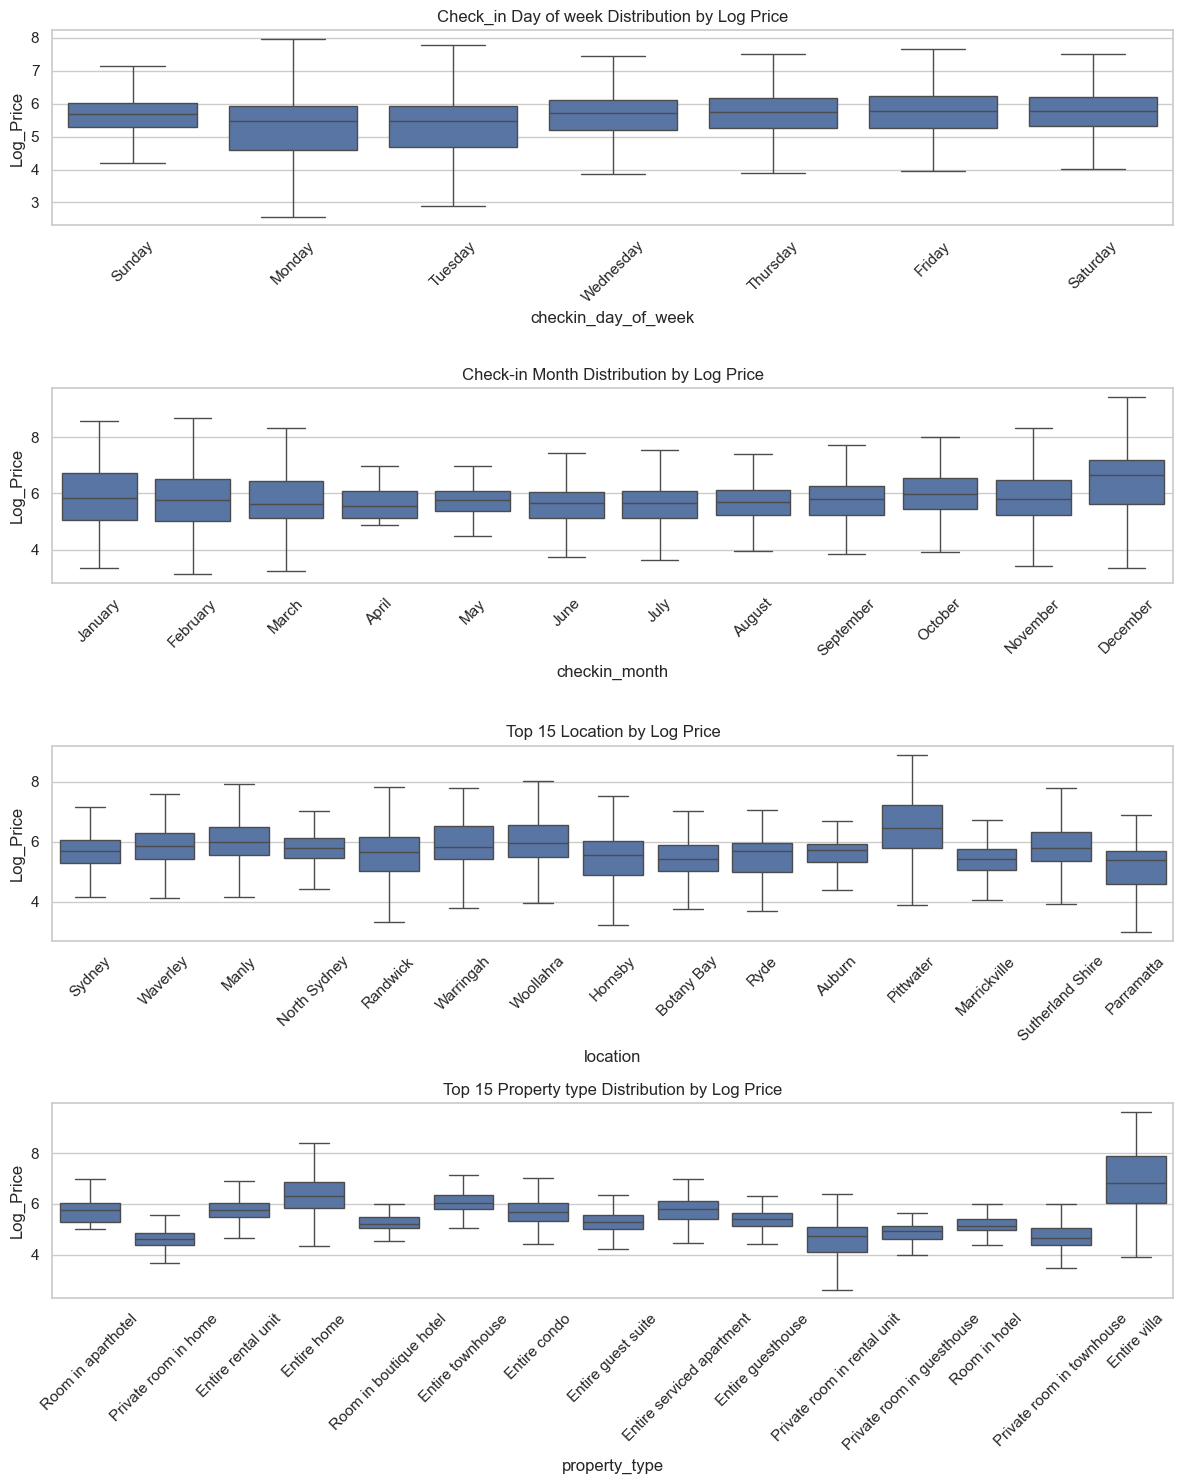

In [26]:
day_order = [
    'Sunday',
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday'
]

month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

fig, axes = plt.subplots(4, 1, figsize = (12,15))
axes = axes.flatten()

sns.boxplot(data = df_eda, x = 'checkin_day_of_week', y = 'Log_Price', ax = axes[0], order = day_order, showfliers=False)
axes[0].set_title('Check_in Day of week Distribution by Log Price')
axes[0].tick_params(axis = 'x', rotation = 45)

sns.boxplot(data = df_eda, x = 'checkin_month', y = 'Log_Price', ax = axes[1], order = month_order, showfliers=False)
axes[1].set_title('Check-in Month Distribution by Log Price')
axes[1].tick_params(axis = 'x', rotation = 45)

sns.boxplot(data = top_15_location_df, x = 'location', y = 'Log_Price', ax = axes[2], showfliers=False)
axes[2].set_title('Top 15 Location by Log Price')
axes[2].tick_params(axis = 'x', rotation = 45)

sns.boxplot(data = top_15_property_type_df, x = 'property_type', y = 'Log_Price', ax = axes[3], showfliers=False)
axes[3].set_title('Top 15 Property type Distribution by Log Price')
axes[3].tick_params(axis = 'x', rotation = 45)

plt.tight_layout()
plt.show()

Median log-prices are similar across weekdays, with slightly higher prices on Friday and Saturday. December has the highest monthly median, but the monthly data is heavily concentrated in June. Prices also vary by location and property type, with Pittwater and entire-property listings generally more expensive, while private rooms are cheaper. Results for less common property types are less conclusive due to their smaller sample sizes.

In [27]:
# Checking the correlation between features and log target
corr = df_eda.drop(columns = [TARGET]).corr(numeric_only=True)
target_corr = corr['Log_Price']

corr_df = pd.DataFrame({
    'correlation': target_corr,
    'absolute_correlation': target_corr.abs()
})
display(corr_df.sort_values(by='absolute_correlation', ascending = False).head(10))
display(corr_df.sort_values(by='absolute_correlation', ascending = False).tail(10))

,correlation,absolute_correlation
Log_Price,1.000000,1.000000
accommodates,0.620041,0.620041
beds,0.580213,0.580213
bedrooms,0.571562,0.571562
stay_length_nights,-0.466580,0.466580
bathrooms,0.455938,0.455938
has_license,0.437646,0.437646
amenity_cnt,0.362025,0.362025
longitude,0.274081,0.274081
has_tub,0.255609,0.255609


,correlation,absolute_correlation
availability_365,-0.097099,0.097099
host_listings_count,0.094325,0.094325
has_parking,0.080468,0.080468
has_wifi,0.050727,0.050727
number_of_reviews_ltm,0.025072,0.025072
number_of_reviews,-0.023119,0.023119
host_has_profile_pic,0.011647,0.011647
host_identity_verified,0.010441,0.010441
number_of_reviews_l30d,0.007720,0.007720
year,NaN,NaN


The correlation results generally support the patterns observed during EDA. Listing capacity features such as accommodates, beds, bedrooms, and bathrooms show the strongest positive relationships with log price, while longer stays are associated with lower prices. Features such as review counts, Wi-Fi, and host verification show little linear relationship with the target.

## 🧹 Data Preprocessing & Feature Engineering

In [28]:
X_train, y_train_log = df_train.drop(columns = [TARGET]), np.log1p(df_train[TARGET])
X_test, y_test = df_test.drop(columns = [TARGET]), df_test[TARGET]

In [29]:
def adding_features(df1):
    df = df1.copy()

    #Log-transform
    skewed_cols = [
        'host_listings_count',
        'number_of_reviews',
        'number_of_reviews_ltm',
        'number_of_reviews_l30d',
        'stay_length_nights'
    ]

    for col in skewed_cols:
        df[f'log_{col}'] = np.log1p(df[col])

    #Discretization
    df['host_size_group'] = pd.cut(
    df['host_listings_count'],
    bins=[0, 5, 20, 100, np.inf],
    labels=[
        '1-5',
        '6–20',
        '21–100',
        '101+'
        ]
    )
    df['stay_length_group'] = pd.cut(
        df['stay_length_nights'],
        bins=[0, 2, 7, 14, 30, 90, np.inf],
        labels=[
            '1–2 nights',
            '3–7 nights',
            '8–14 nights',
            '15–30 nights',
            '31–90 nights',
            '91+ nights'
            ],
    )
    df['has_recent_review'] = np.where(
        df['number_of_reviews_l30d'].isna(), 
        np.nan,
        np.where(
            df['number_of_reviews_l30d'] > 0,
            'Has recent review',
            'No recent review'
        )
    )
    df['is_unreviewed'] = (df['number_of_reviews'] == 0).astype(int)
    
    df['beds_per_guest'] = df['beds'] / df['accommodates']
    df['bedrooms_per_guest'] = df['bedrooms'] / df['accommodates']
    df['bathrooms_per_guest'] = df['bathrooms'] / df['accommodates']
    df['beds_per_bedroom'] = (df['beds']) / df['bedrooms'].replace(0, np.nan)

    
    #Cyclic encoder
    df['checkin_month_sin'] = np.sin(2 * np.pi * df['checkin_month'] / 12)
    df['checkin_month_cos'] = np.cos(2 * np.pi * df['checkin_month'] / 12)
    
    df['checkin_day_sin'] = np.sin(2 * np.pi * df['checkin_day_of_week'] / 7)
    df['checkin_day_cos'] = np.cos(2 * np.pi * df['checkin_day_of_week'] / 7)
    
    df['is_fri_sat_night_checkin'] = (df['checkin_day_of_week'].isin([4, 5])).astype(int)

    return df

In [30]:
engineered_cols = [
    'log_host_listings_count',
    'log_number_of_reviews',
    'log_number_of_reviews_ltm',
    'log_number_of_reviews_l30d',
    'log_stay_length_nights',
    'beds_per_guest',
    'bedrooms_per_guest',
    'bathrooms_per_guest',
    'beds_per_bedroom',
    'is_unreviewed',
    'checkin_month_sin',
    'checkin_month_cos',
    'checkin_day_sin',
    'checkin_day_cos',
    'is_fri_sat_night_checkin'
]

categorical_cols = [
    'location',
    'property_type',
    'room_type',
    'host_size_group',
    'stay_length_group',
    'has_recent_review'
]

excluded_cols = [
    'listing_id',
    'year',
    'checkin_month',
    'checkin_day_of_week',
    'availability_90',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'host_listings_count',
    'number_of_reviews',
    'number_of_reviews_ltm',
    'number_of_reviews_l30d',
    'stay_length_nights'
]

numerical_cols = [
    col
    for col in X_train.select_dtypes(include='number').columns
    if col not in excluded_cols
]

#Use the feature engineer function in pipeline later
feature_engineering = FunctionTransformer(adding_features)

# Use median imputation because some numerical features contain outliers.
# Add missing-value indicators so the model can distinguish imputed values from observed values.
numeric_preprocess = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median', add_indicator = True)),
    ('scaler', StandardScaler())
])

#Use constant becuase that is more transparent and lets the model decide whether those records behave differently
categorical_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'Missing')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

column_preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_preprocess, numerical_cols + engineered_cols),
        ('cat', categorical_preprocess, categorical_cols)
    ],
    verbose_feature_names_out = False
)

preprocessor = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('column_preprocessor', column_preprocessor)
])

In [31]:
#Preview
engineered_preview = adding_features(X_train.head())
display(engineered_preview.head())

,listing_id,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,location,latitude,longitude,property_type,room_type,accommodates,bedrooms,bathrooms,beds,availability_30,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,year,amenity_cnt,has_wifi,has_air_conditioning,has_kitchen,has_parking,has_pool,has_washer,has_water_view,pets_allowed,has_tub,has_heating,has_license,checkin_month,checkin_day_of_week,stay_length_nights,log_host_listings_count,log_number_of_reviews,log_number_of_reviews_ltm,log_number_of_reviews_l30d,log_stay_length_nights,host_size_group,stay_length_group,has_recent_review,is_unreviewed,beds_per_guest,bedrooms_per_guest,bathrooms_per_guest,beds_per_bedroom,checkin_month_sin,checkin_month_cos,checkin_day_sin,checkin_day_cos,is_fri_sat_night_checkin
781,11441680,0,8,1,1,Sydney,-33.885610,151.180470,Room in aparthotel,Private room,3,1.0,1.0,2.0,16,69,342,180,13,0,4.47,4.62,4.54,4.62,4.57,4.64,4.33,2026,55,1,1,1,1,0,1,0,1,0,1,1,6.0,6.0,1.0,2.197225,5.198497,2.639057,0.0,0.693147,6–20,1–2 nights,No recent review,0,0.666667,0.333333,0.333333,2.0,1.224647e-16,-1.000000,-0.781831,0.623490,0
16720,1677624005258482672,0,21,1,1,Holroyd,-33.827381,150.992560,Private room in home,Private room,2,1.0,3.0,1.0,15,75,348,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,37,0,0,1,1,0,1,0,0,0,0,1,7.0,3.0,3.0,3.091042,0.000000,0.000000,0.0,1.386294,21–100,3–7 nights,No recent review,1,0.500000,0.500000,1.500000,1.0,-5.000000e-01,-0.866025,0.433884,-0.900969,0
2944,38988521,0,1,1,1,Waverley,-33.889130,151.269540,Entire rental unit,Entire home/apt,6,3.0,2.0,3.0,30,85,126,41,7,0,4.95,4.98,4.83,4.98,5.00,5.00,4.71,2026,50,1,1,1,1,0,1,0,1,1,1,1,6.0,2.0,3.0,0.693147,3.737670,2.079442,0.0,1.386294,1-5,3–7 nights,No recent review,0,0.500000,0.500000,0.333333,1.0,1.224647e-16,-1.000000,0.974928,-0.222521,0
9594,1260521970679337532,0,1,1,1,Manly,-33.801757,151.287920,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,25,83,331,68,33,0,4.82,4.93,4.88,4.93,4.87,4.97,4.71,2026,14,0,0,1,0,1,1,0,0,0,0,1,6.0,2.0,2.0,0.693147,4.234107,3.526361,0.0,1.098612,1-5,1–2 nights,No recent review,0,0.500000,0.500000,0.500000,1.0,1.224647e-16,-1.000000,0.974928,-0.222521,0
2945,39006421,1,18,1,1,Waverley,-33.887840,151.273193,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,17,77,107,233,16,0,4.88,4.91,4.88,4.98,4.98,4.97,4.85,2026,53,1,1,1,1,0,1,0,0,0,1,1,6.0,1.0,21.0,2.944439,5.455321,2.833213,0.0,3.091042,6–20,15–30 nights,No recent review,0,0.500000,0.500000,0.500000,1.0,1.224647e-16,-1.000000,0.781831,0.623490,0


In [32]:
X_train_processed = preprocessor.fit_transform(X_train, y_train_log)

#Feature Selection
selector = SelectKBest(f_regression, k = 100)

selector.fit_transform(X_train_processed, y_train_log)

feature_names = preprocessor.named_steps['column_preprocessor'].get_feature_names_out()

feature_scores = (pd.DataFrame({
    'feature': feature_names,
    'score': selector.scores_,
}).sort_values('score', ascending = False).reset_index(drop=True))

feature_scores.head(15)

,feature,score
0,accommodates,8884.453984
1,room_type_Entire home/apt,6935.158416
2,room_type_Private room,6690.268512
3,missingindicator_beds_per_bedroom,4547.610885
4,beds,4419.511061
5,bedrooms,4341.634679
6,bathrooms,3737.118286
7,stay_length_group_31–90 nights,3645.459784
8,has_license,3370.046610
9,property_type_Private room in home,3318.681097


Several features ranked among the top 15 by SelectKBest also showed strong relationships with the target in the correlation analysis.

In [33]:
#Apply Cross-Validation to find the best model
cv = KFold(
    n_splits = 5,
    shuffle= True,
    random_state= RANDOM_STATE
)

models = {
    'Dummy' : DummyRegressor(strategy= 'median'), #Baseline model

    'lin_reg' : LinearRegression(),

    'ridge' : Ridge(),

    'RF' : RandomForestRegressor(random_state = RANDOM_STATE),

    'GB' : GradientBoostingRegressor(random_state = RANDOM_STATE),

    'XGBoost' : XGBRegressor(random_state = RANDOM_STATE)
}

#Regression model scoring
scoring = {
    'mae_log_scale': 'neg_mean_absolute_error',
    'rmsle': 'neg_root_mean_squared_error',
    'r2_log_scale': 'r2'
}

def build_pipeline(estimator):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=100)), 
        ('model', estimator)
    ])

pipelines = {}
res = []

for name, estimator in models.items():
    pipeline = build_pipeline(estimator)
    pipelines[name] = pipeline

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train_log,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    res.append({
        'Model': name,
        'MAE (log scale)': -cv_results['test_mae_log_scale'].mean(),
        'RMSLE': -cv_results['test_rmsle'].mean(),
        'R² (log scale)': cv_results['test_r2_log_scale'].mean()
    })

comparison = (
    pd.DataFrame(res)
    .sort_values('RMSLE', ascending=True)
    .reset_index(drop=True)
)

display(comparison)

,Model,MAE (log scale),RMSLE,R² (log scale)
0,XGBoost,0.242003,0.352561,0.843246
1,RF,0.249195,0.366170,0.830926
2,GB,0.268532,0.379405,0.818497
3,ridge,0.281674,0.394045,0.804341
4,lin_reg,0.281710,0.394107,0.804289
5,Dummy,0.654157,0.893186,-0.004111


XGBoost was selected because it achieved the best cross-validation performance. Tree-based models also outperformed linear models, suggesting that Airbnb prices involve nonlinear relationships and feature interactions that XGBoost can effectively capture.

In [34]:
#Random Search CV for the best parameters
#Use xgb without SelectKBest
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

params = {
    'model__n_estimators': [100, 400, 1000],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 4, 5, 6, 8],
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=params,
    scoring='neg_root_mean_squared_error',
    n_iter=50,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
    random_state=RANDOM_STATE
)

xgb_random_search.fit(X_train, y_train_log)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 400, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [35]:
print(
    'Best CV RMSE (Log scaled):',
    -xgb_random_search.best_score_
)

print('Best parameters:')

for parameter, value in xgb_random_search.best_params_.items():
    print(f'{parameter}: {value}')

Best CV RMSE (Log scaled): 0.33712450971972047
Best parameters:
model__n_estimators: 1000
model__max_depth: 5
model__learning_rate: 0.1


The best-performing XGBoost model used the following parameters:
* n_estimators: 1,000
* max_depth: 5
* learning_rate: 0.1
  
After tuning, the cross-validated RMSLE improved from 0.353 to 0.337.

In [36]:
best_xgb = xgb_random_search.best_estimator_

test_predictions_log = best_xgb.predict(X_test)
test_predictions_aud = np.expm1(test_predictions_log)
y_test_log = np.log1p(y_test)

print(f'Test MAE (AUD/night): ${mean_absolute_error(y_test, test_predictions_aud):,.2f}')

print(f'Test RMSE (AUD/night): ${root_mean_squared_error(y_test, test_predictions_aud):,.2f}')

print(f'Test R² (raw-price scale): {r2_score(y_test, test_predictions_aud):.3f}')

#log-price scale
print(f'Test MAE (log-price scale): {mean_absolute_error(y_test_log, test_predictions_log):.3f}')

print(f'Test RMSLE: {root_mean_squared_error(y_test_log, test_predictions_log):.3f}')

print(f'Test R² (log-price scale) {r2_score(y_test_log, test_predictions_log):.3f}')

Test MAE (AUD/night): $141.74
Test RMSE (AUD/night): $1,233.71
Test R² (raw-price scale): 0.158
Test MAE (log-price scale): 0.226
Test RMSLE: 0.360
Test R² (log-price scale) 0.845


The model explained 84.5% of the variation in log-transformed nightly prices and achieved an RMSLE of 0.360. However, performance was considerably weaker on the original price scale, with an MAE of approximately $142 per night and an RMSE of $1,234. The large difference between MAE and RMSE indicates that a small number of high-priced listings produced exceptionally large prediction errors. Therefore, the model captures general and proportional pricing patterns well but is less reliable for extreme high-price listings.

In [37]:
#Analyse the largest prediction errors
residual_analysis = X_test[
    [
        'listing_id',
        'location',
        'property_type',
        'room_type'
    ]
].copy()

residual_analysis['actual_price'] = y_test.to_numpy()
residual_analysis['predicted_price'] = test_predictions_aud

residual_analysis['error'] = residual_analysis['actual_price'] - residual_analysis['predicted_price']

residual_analysis['squared_error'] = residual_analysis['error'] ** 2

largest_errors = residual_analysis.sort_values('squared_error', ascending=False).head(15)

top_15_error_share = largest_errors['squared_error'].sum() / residual_analysis['squared_error'].sum()

display(largest_errors)
print(f'Top 15 share of total squared error: {top_15_error_share:.1%}')

,listing_id,location,property_type,room_type,actual_price,predicted_price,error,squared_error
6762,948190865551462634,North Sydney,Entire rental unit,Entire home/apt,52850.000000,765.657227,52084.342773,2.712779e+09
8887,1192424755970639194,Sydney,Entire townhouse,Entire home/apt,33687.820000,165.199081,33522.620919,1.123766e+09
8671,1172314473011066918,Sydney,Entire home,Entire home/apt,33351.630000,195.320114,33156.309886,1.099341e+09
7294,1014943086398898860,Fairfield,Private room in home,Private room,11459.500000,168.336349,11291.163651,1.274904e+08
9355,1239359995329089142,Woollahra,Entire home,Entire home/apt,5912.142857,14881.192383,-8969.049526,8.044385e+07
11397,1409881130441504743,Waverley,Entire home,Entire home/apt,8455.200000,3695.773438,4759.426563,2.265214e+07
17597,1705656745850054525,Sydney,Entire rental unit,Entire home/apt,4500.000000,745.210266,3754.789734,1.409845e+07
6738,944416172331600937,Waverley,Entire home,Entire home/apt,8295.000000,4568.880371,3726.119629,1.388397e+07
11718,1436003129758433697,Waverley,Entire home,Entire home/apt,5529.000000,2098.014648,3430.985352,1.177166e+07
15647,1637263398708920515,Pittwater,Entire home,Entire home/apt,6206.250000,2892.066406,3314.183594,1.098381e+07


Top 15 share of total squared error: 97.1%


The model generalises well for typical listings and effectively captures proportional pricing patterns. However, it substantially underpredicts a small number of extremely high-priced listings. The 15 largest errors account for 97.1% of the total squared error, dominating the raw-price RMSE and contributing to the low raw-price R². Therefore, although the model is reliable for most listings, its predictions are less dependable for the highest-priced properties.

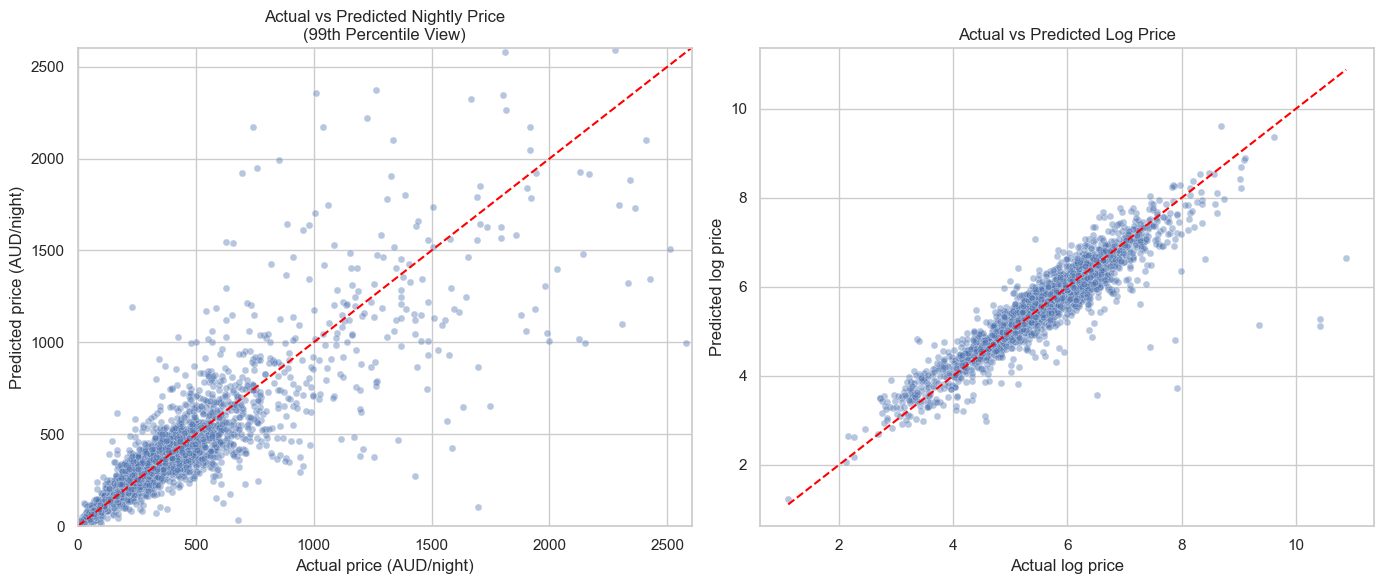

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw-price scale
sns.scatterplot(
    x=y_test,
    y=test_predictions_aud,
    alpha=0.4,
    s=25,
    ax=axes[0]
)

raw_min = min(y_test.min(), test_predictions_aud.min())
raw_max = max(y_test.max(), test_predictions_aud.max())

axes[0].plot(
    [raw_min, raw_max],
    [raw_min, raw_max],
    color='red',
    linestyle='--'
)

raw_limit = np.quantile(
    np.concatenate([
        y_test.to_numpy(),
        test_predictions_aud
    ]),
    0.99
)
axes[0].set_xlim(0, raw_limit)
axes[0].set_ylim(0, raw_limit)
axes[0].set_title('Actual vs Predicted Nightly Price\n(99th Percentile View)')
axes[0].set_xlabel('Actual price (AUD/night)')
axes[0].set_ylabel('Predicted price (AUD/night)')


# Log-price scale
sns.scatterplot(
    x=y_test_log,
    y=test_predictions_log,
    alpha=0.4,
    s=25,
    ax=axes[1]
)

log_min = min(y_test_log.min(), test_predictions_log.min())
log_max = max(y_test_log.max(), test_predictions_log.max())

axes[1].plot(
    [log_min, log_max],
    [log_min, log_max],
    color='red',
    linestyle='--'
)

axes[1].set_title('Actual vs Predicted Log Price')
axes[1].set_xlabel('Actual log price')
axes[1].set_ylabel('Predicted log price')

plt.tight_layout()
plt.show()

Within the first 99% of the price distribution, predictions generally follow actual prices, particularly for lower and moderately priced listings. However, prediction variability increases with price, and the model tends to underpredict more expensive properties. The relationship is considerably tighter on the log-price scale, showing that the model captures proportional price differences better than absolute dollar differences.

In [39]:
#Permutation Importance
permutation_result = permutation_importance(
    best_xgb,
    X_test,
    y_test_log,
    scoring='neg_root_mean_squared_error',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_df = (
    pd.DataFrame({
        'feature': X_test.columns,
        'importance': permutation_result.importances_mean
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

display(permutation_df.head(15))

,feature,importance
0,stay_length_nights,0.370814
1,room_type,0.138397
2,accommodates,0.114335
3,longitude,0.111958
4,bedrooms,0.096077
5,latitude,0.039673
6,host_listings_count,0.028574
7,checkin_month,0.028073
8,bathrooms,0.020469
9,number_of_reviews_ltm,0.019782


Permutation importance indicated that stay length was the most influential original feature, followed by room type, accommodation capacity, longitude, and bedrooms. This suggests that booking duration, room type, property size, and location are the primary factors used by the model to predict nightly prices.

## 🏠 Project Summary

### 🎯 Objective

This project aimed to predict the nightly price a user could expect to pay for an Airbnb stay in Sydney based on booking requirements and listing characteristics.

### 🛠️ Approach

After cleaning the data and engineering relevant features, several regression models were evaluated using five-fold cross-validation. XGBoost achieved the best performance and was selected for hyperparameter tuning.

The best-performing model used:

- **Number of trees:** 1,000
- **Maximum tree depth:** 5
- **Learning rate:** 0.1

Hyperparameter tuning improved the cross-validated RMSLE from **0.353 to 0.337**.

### 📊 Test Performance

**Original AUD price scale:**

- **MAE:** \$141.74 per night
- **RMSE:** \$1,233.71 per night
- **R²:** 0.158

**Log-price scale:**

- **MAE:** 0.226
- **RMSLE:** 0.360
- **R²:** 0.845

The model captures general and proportional pricing patterns well, although extreme prices substantially affect its performance on the original AUD scale.

### 🔍 Key Predictors

Permutation importance identified the most influential predictors as:

1. Stay length
2. Room type
3. Accommodation capacity
4. Longitude
5. Number of bedrooms
6. Latitude

These results suggest that booking duration, room type, property size, and location are the main factors used by the model to estimate nightly prices.

### ⚠️ Limitations

The model performs well for typical Sydney listings but substantially underpredicts several extremely expensive properties. The 15 largest prediction errors account for **97.1% of the total squared error**, resulting in a high raw-price RMSE and low raw-price R².

### ✅ Conclusion

Overall, the XGBoost model provides useful nightly-price estimates for typical Airbnb listings in Sydney based on booking requirements and listing characteristics. However, predictions for extreme high-priced properties should be treated with caution.